In [1]:
import pandas as pd, numpy as np
df = pd.read_csv("banking_anomaly.csv")
print("Shape:", df.shape)
df.head()

Shape: (6831, 11)


,bank_txn_id,date,txn_type,amount_abs_rs,direction,channel,weekday,day_of_month,created_offline,amount_zscore,target_anomaly
0,BNK00001,2022-06-13,cash_deposit,13680.83,in,agency_banking_agent,0,13,0,-1.29,0
1,BNK00002,2022-06-13,qr_settlement,2528.00,in,LankaQR,0,13,0,-0.88,0
2,BNK00003,2022-06-13,card_settlement,432.00,in,POS_card,0,13,0,-1.16,0
3,BNK00004,2022-06-14,cash_deposit,18153.03,in,agency_banking_agent,1,14,0,-0.91,0
4,BNK00005,2022-06-14,qr_settlement,1666.00,in,LankaQR,1,14,0,-1.06,0


In [2]:
print("Missing:", df.isnull().sum().sum(), "| Duplicates:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# identifiers, not features
df = df.drop(columns=["bank_txn_id", "date"])
# make boolean numeric
df["created_offline"] = df["created_offline"].astype(int)
# one-hot encode text columns
df_clean = pd.get_dummies(df, columns=["txn_type", "direction", "channel"], drop_first=False)
print("Shape after encoding:", df_clean.shape)
df_clean.head()

Missing: 0 | Duplicates: 0
Shape after encoding: (6831, 16)


,amount_abs_rs,weekday,day_of_month,created_offline,amount_zscore,target_anomaly,txn_type_card_settlement,txn_type_cash_deposit,txn_type_qr_settlement,txn_type_supplier_payment,direction_in,direction_out,channel_LankaQR,channel_POS_card,channel_agency_banking_agent,channel_bank_transfer
0,13680.83,0,13,0,-1.29,0,False,True,False,False,True,False,False,False,True,False
1,2528.00,0,13,0,-0.88,0,False,False,True,False,True,False,True,False,False,False
2,432.00,0,13,0,-1.16,0,True,False,False,False,True,False,False,True,False,False
3,18153.03,1,14,0,-0.91,0,False,True,False,False,True,False,False,False,True,False
4,1666.00,1,14,0,-1.06,0,False,False,True,False,True,False,True,False,False,False


In [3]:
X = df_clean.drop(columns=["target_anomaly"])
y = df_clean["target_anomaly"]
print("Anomaly rate:", round(y.mean(), 3), "| anomalies:", int(y.sum()))

Anomaly rate: 0.041 | anomalies: 279


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0],
      "| test anomalies:", int(y_test.sum()))

Train: 5123 | Test: 1708 | test anomalies: 70


In [5]:
from xgboost import XGBClassifier
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale = neg / pos     # tells XGBoost to weight the rare class more

model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                      subsample=0.9, scale_pos_weight=scale,
                      eval_metric="logloss", random_state=42)
model.fit(X_train, y_train)
print("Model trained ✓ (scale_pos_weight =", round(scale,1), ")")

Model trained ✓ (scale_pos_weight = 23.5 )


ROC-AUC: 0.886
              precision    recall  f1-score   support

      normal       0.99      0.99      0.99      1638
     anomaly       0.79      0.74      0.76        70

    accuracy                           0.98      1708
   macro avg       0.89      0.87      0.88      1708
weighted avg       0.98      0.98      0.98      1708



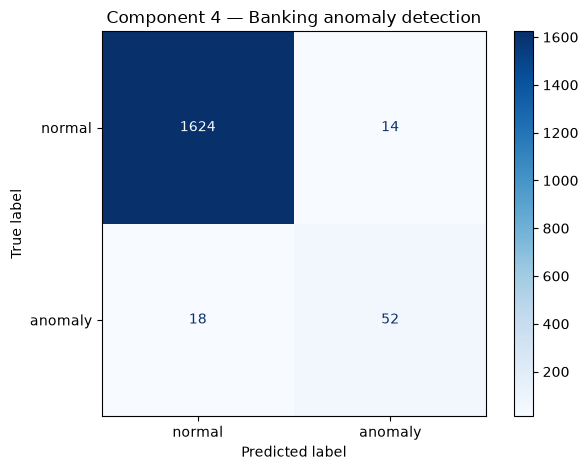

In [6]:
from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
    display_labels=["normal", "anomaly"], cmap="Blues")
plt.title("Component 4 — Banking anomaly detection"); plt.tight_layout(); plt.show()

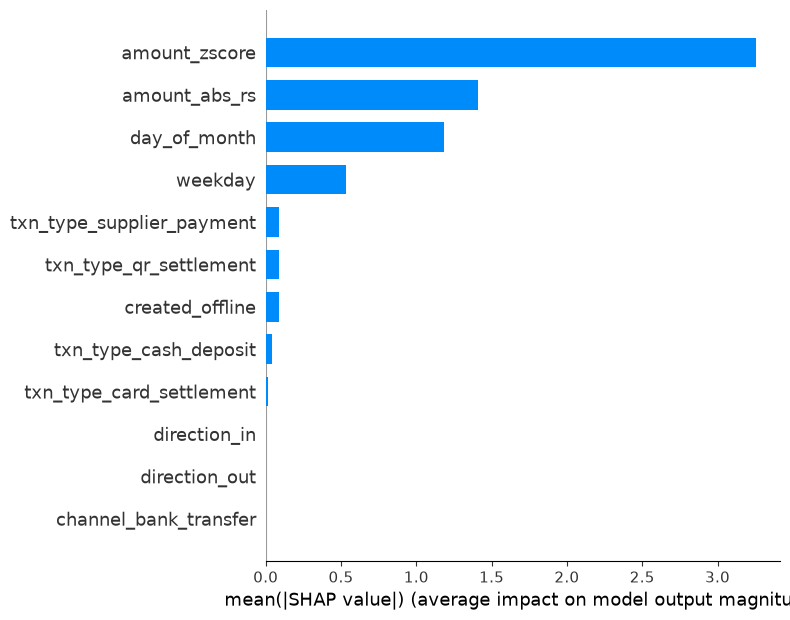

In [7]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=12)

In [8]:
import joblib
joblib.dump(model, "component4_banking_anomaly_model.pkl")
print("Saved as component4_banking_anomaly_model.pkl")

Saved as component4_banking_anomaly_model.pkl
